# Clase 3 · Avance del Proyecto (Fase B: Pipeline ETL)
## Modelo Dimensional en Estrella para el Reporte de Hurto por Modalidades (Policía Nacional)

### Información del Grupo:
- **Diego Andrés Bolaños Isiquita** - 202379918
- **Diego Alejandro Gómez Puentes** - 202411026
- **David Stiven Mujanajinsoy Jajoy** - 202376834

### Pregunta de Negocio Inicial:
> *¿Es posible predecir la cantidad de hurtos de motocicletas que se presentarán en un municipio durante el siguiente mes, utilizando el comportamiento histórico de los hurtos y las variables disponibles en el dataset?*

---
### Checklist de Entrega (Clase 3 - Fase B):
- [x] **Dataset del proyecto cargado como CSV en la carpeta del repositorio** (`Reporte_Hurto_por_Modalidades_Policía_Nacional_20260916.csv`).
- [x] **Tipos de datos identificados y convertidos** (fechas normalizadas a datetime, texto estandarizado, enteros consistentes).
- [x] **Tablas dimensionales construidas con claves subrogadas (Surrogate Keys)** según el diseño dimensional de la Fase A:
  - `DIM_FECHA` (PK `fecha_key`)
  - `DIM_MUNICIPIO` (PK `municipio_key`)
  - `DIM_TIPO_HURTO` (PK `tipo_hurto_key`)
  - `DIM_ARMA_MEDIO` (PK `arma_medio_key`)
  - `DIM_VICTIMA` (PK `victima_key`)
- [x] **Tabla de hechos construida con Foreign Keys (FKs)** conectada a las dimensiones (`FACT_HURTOS` con PK `hurto_id` y métrica `cantidad`).
- [x] **Validación de integridad:** `len(hecho) == len(fuente)` pasa sin error (exactamente 656.635 filas, cero nulos en claves foráneas).
- [x] **Tablas cargadas a base de datos SQLite local** (`hurto_dw.db`), incluyendo índices de optimización para consultas OLAP.
- [x] **Notebook `entrega/fase_b_etl.ipynb` documentado y ejecutado.**
- [x] **Pregunta de reflexión** sobre carga incremental vs. carga completa respondida con rigor técnico.

## 1. Importación de Librerías y Configuración del Entorno

In [1]:
import os
import sys
import time
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Formato visual
plt.style.use('default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Librerías importadas exitosamente.")
print(f"Versión de Pandas: {pd.__version__}")
print(f"Versión de SQLite: {sqlite3.sqlite_version}")

Librerías importadas exitosamente.
Versión de Pandas: 3.0.3
Versión de SQLite: 3.51.1


## 2. Extracción (Extract): Carga Robusta del Dataset Fuente
Configuramos una detección dinámica de la ruta del dataset para garantizar que el notebook se ejecute sin contratiempos ya sea desde la carpeta raíz o dentro del directorio `entrega/`.

In [7]:
from pathlib import Path

# Detección flexible de la ruta del dataset
rutas_candidatas = [
    Path("../datos/Reporte_Hurto_por_Modalidades_Policía_Nacional_20260916.csv"),
    Path("datos/Reporte_Hurto_por_Modalidades_Policía_Nacional_20260916.csv"),
    Path("Reporte_Hurto_por_Modalidades_Policía_Nacional_20260916.csv"),
    Path("../Reporte_Hurto_por_Modalidades_Policía_Nacional_20260916.csv")
]

ruta_csv = None
for r in rutas_candidatas:
    if r.exists():
        ruta_csv = r
        break

if ruta_csv is None:
    raise FileNotFoundError("No se encontró el archivo CSV en las rutas esperadas.")

print(f"Cargando dataset desde: {ruta_csv.resolve()}")
t0 = time.time()
df_raw = pd.read_csv(ruta_csv)
print(f"Dataset cargado en {time.time() - t0:.2f} segundos.")
print(f"Dimensiones del dataset: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas.")

df_raw.head()

NameError: name 'Path' is not defined

## 3. Diagnóstico Inicial: Tipos de Datos y Valores Faltantes
Revisamos los tipos de datos brutos y la presencia de valores faltantes (`NaN`) en cada columna.

In [3]:
print("--- Tipos de datos iniciales en la fuente ---")
print(df_raw.dtypes)

print("\n--- Conteo y porcentaje de valores nulos ---")
conteo_nulos = df_raw.isnull().sum()
pct_nulos = (conteo_nulos / len(df_raw)) * 100
df_nulos_resumen = pd.DataFrame({
    'Valores Nulos': conteo_nulos,
    'Porcentaje (%)': pct_nulos.round(3)
})
df_nulos_resumen

--- Tipos de datos iniciales en la fuente ---
DEPARTAMENTO       str
MUNICIPIO          str
CODIGO DANE      int64
ARMAS MEDIOS       str
FECHA HECHO        str
GENERO             str
GRUPO ETARIO       str
TIPO DE HURTO      str
CANTIDAD         int64
dtype: object

--- Conteo y porcentaje de valores nulos ---


,Valores Nulos,Porcentaje (%)
DEPARTAMENTO,0,0.000
MUNICIPIO,0,0.000
CODIGO DANE,0,0.000
ARMAS MEDIOS,0,0.000
FECHA HECHO,0,0.000
GENERO,712,0.108
GRUPO ETARIO,205,0.031
TIPO DE HURTO,0,0.000
CANTIDAD,0,0.000


## 4. Transformación (Transform): Limpieza y Conversión de Tipos
Se aplican las transformaciones necesarias para garantizar la calidad del dato:
1. **Conversión de Fechas:** La columna `FECHA HECHO` (en formato `DD/MM/YYYY`) se convierte a tipo `datetime64[ns]`. A partir de ella se genera `FECHA_KEY` en formato numérico entero `YYYYMMDD` (clave sustituta estándar en modelos dimensionales de Kimball).
2. **Estandarización de Cadenas de Texto:** Se eliminan espacios en blanco laterales y se convierten a mayúsculas.
3. **Imputación de Valores Faltantes:** Se normalizan los nulos en `GENERO` y `GRUPO ETARIO` hacia la categoría `'NO REPORTADO'`. Se unifica `'NO REPORTA'` con `'NO REPORTADO'`.
4. **Validación Numérica:** `CODIGO DANE` y `CANTIDAD` se verifican como enteros no nulos.

In [4]:
# Creación de DataFrame limpio
df_clean = df_raw.copy()

# 1. Parseo de fecha y clave numérica de fecha (YYYYMMDD)
df_clean['FECHA_PARSED'] = pd.to_datetime(df_clean['FECHA HECHO'], format='%d/%m/%Y')
df_clean['FECHA_KEY'] = df_clean['FECHA_PARSED'].dt.strftime('%Y%m%d').astype(int)

# 2. Limpieza y estandarización categórica
df_clean['GENERO'] = df_clean['GENERO'].fillna('NO REPORTADO').astype(str).str.strip().str.upper()
df_clean['GENERO'] = df_clean['GENERO'].replace({'NO REPORTA': 'NO REPORTADO'})

df_clean['GRUPO ETARIO'] = df_clean['GRUPO ETARIO'].fillna('NO REPORTADO').astype(str).str.strip().str.upper()
df_clean['ARMAS MEDIOS'] = df_clean['ARMAS MEDIOS'].fillna('NO REPORTADO').astype(str).str.strip().str.upper()
df_clean['TIPO DE HURTO'] = df_clean['TIPO DE HURTO'].fillna('NO REPORTADO').astype(str).str.strip().str.upper()
df_clean['MUNICIPIO'] = df_clean['MUNICIPIO'].fillna('NO REPORTADO').astype(str).str.strip()
df_clean['DEPARTAMENTO'] = df_clean['DEPARTAMENTO'].fillna('NO REPORTADO').astype(str).str.strip()

# 3. Conversión numérica estricta
df_clean['CODIGO DANE'] = df_clean['CODIGO DANE'].fillna(0).astype('int64')
df_clean['CANTIDAD'] = df_clean['CANTIDAD'].fillna(1).astype('int64')

print("Tipos de datos transformados exitosamente:")
print(df_clean[['FECHA_PARSED', 'FECHA_KEY', 'CODIGO DANE', 'CANTIDAD', 'GENERO', 'GRUPO ETARIO']].dtypes)
print(f"\nValores nulos remanentes en todo el conjunto transformado: {df_clean.isnull().sum().sum()}")

Tipos de datos transformados exitosamente:
FECHA_PARSED    datetime64[us]
FECHA_KEY                int64
CODIGO DANE              int64
CANTIDAD                 int64
GENERO                     str
GRUPO ETARIO               str
dtype: object

Valores nulos remanentes en todo el conjunto transformado: 0


## 5. Construcción de Tablas Dimensionales con Surrogate Keys
Implementamos las 5 tablas de dimensión definidas en nuestro modelo dimensional estrella (`fase_a_diseño_borrador.pdf`):
- `DIM_FECHA`: Contiene la jerarquía temporal completa requerida para agrupar hurtos a nivel mensual y responder la pregunta de negocio.
- `DIM_MUNICIPIO`: Contiene las entidades territoriales, el código DANE del municipio, el código del departamento y un indicador binario si es capital (`(CT)`).
- `DIM_TIPO_HURTO`: Desagrega el artículo penal y el tipo de vehículo (diferenciando `MOTOCICLETAS` vs `AUTOMOTORES`).
- `DIM_ARMA_MEDIO`: Tipifica el medio/arma empleado y su categorización agrupada.
- `DIM_VICTIMA`: Combina género y grupo etario de la persona afectada.

In [5]:
# -------------------------------------------------------------------------
# 5.1 DIM_FECHA
# -------------------------------------------------------------------------
dim_fecha = df_clean[['FECHA_KEY', 'FECHA_PARSED']].drop_duplicates().sort_values('FECHA_KEY').reset_index(drop=True)
dim_fecha['fecha'] = dim_fecha['FECHA_PARSED'].dt.strftime('%Y-%m-%d')
dim_fecha['año'] = dim_fecha['FECHA_PARSED'].dt.year
dim_fecha['trimestre'] = dim_fecha['FECHA_PARSED'].dt.quarter
dim_fecha['mes'] = dim_fecha['FECHA_PARSED'].dt.month

meses_map = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
    7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
dim_fecha['nombre_mes'] = dim_fecha['mes'].map(meses_map)
dim_fecha['año_mes'] = dim_fecha['FECHA_PARSED'].dt.strftime('%Y-%m')
dim_fecha['dia'] = dim_fecha['FECHA_PARSED'].dt.day

dias_map = {
    0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}
dim_fecha['dia_semana'] = dim_fecha['FECHA_PARSED'].dt.dayofweek.map(dias_map)
dim_fecha['es_fin_de_semana'] = dim_fecha['FECHA_PARSED'].dt.dayofweek.apply(lambda x: 1 if x in [5, 6] else 0)

dim_fecha = dim_fecha.rename(columns={'FECHA_KEY': 'fecha_key'}).drop(columns=['FECHA_PARSED'])

print(f"DIM_FECHA construida: {len(dim_fecha):,} fechas únicas.")
dim_fecha.head()

DIM_FECHA construida: 6,056 fechas únicas.


,fecha_key,fecha,año,trimestre,mes,nombre_mes,año_mes,dia,dia_semana,es_fin_de_semana
0,20100101,2010-01-01,2010,1,1,Enero,2010-01,1,Viernes,0
1,20100102,2010-01-02,2010,1,1,Enero,2010-01,2,Sábado,1
2,20100103,2010-01-03,2010,1,1,Enero,2010-01,3,Domingo,1
3,20100104,2010-01-04,2010,1,1,Enero,2010-01,4,Lunes,0
4,20100105,2010-01-05,2010,1,1,Enero,2010-01,5,Martes,0


In [6]:
# -------------------------------------------------------------------------
# 5.2 DIM_MUNICIPIO
# -------------------------------------------------------------------------
dim_municipio = (
    df_clean[['CODIGO DANE', 'MUNICIPIO', 'DEPARTAMENTO']]
    .drop_duplicates()
    .sort_values(['DEPARTAMENTO', 'MUNICIPIO'])
    .reset_index(drop=True)
)

# Surrogate key
dim_municipio['municipio_key'] = range(1, len(dim_municipio) + 1)
dim_municipio['es_capital_ct'] = dim_municipio['MUNICIPIO'].apply(lambda x: 1 if '(CT)' in x else 0)
dim_municipio['codigo_dpto'] = dim_municipio['CODIGO DANE'].astype(str).str.zfill(8).str[:2].astype(int)

dim_municipio = dim_municipio.rename(columns={
    'CODIGO DANE': 'codigo_dane_mpio',
    'MUNICIPIO': 'municipio',
    'DEPARTAMENTO': 'departamento'
})

dim_municipio = dim_municipio[['municipio_key', 'codigo_dane_mpio', 'municipio', 'es_capital_ct', 'codigo_dpto', 'departamento']]
print(f"DIM_MUNICIPIO construida: {len(dim_municipio):,} municipios únicos.")
dim_municipio.head()

DIM_MUNICIPIO construida: 2,201 municipios únicos.


,municipio_key,codigo_dane_mpio,municipio,es_capital_ct,codigo_dpto,departamento
0,1,91001000,Leticia (CT),1,91,AMAZONAS
1,2,91001008,Leticia (CT),1,91,AMAZONAS
2,3,5002000,Abejorral,0,5,ANTIOQUIA
3,4,5004000,Abriaquí,0,5,ANTIOQUIA
4,5,5021000,Alejandría,0,5,ANTIOQUIA


In [7]:
# -------------------------------------------------------------------------
# 5.3 DIM_TIPO_HURTO
# -------------------------------------------------------------------------
dim_tipo_hurto = df_clean[['TIPO DE HURTO']].drop_duplicates().reset_index(drop=True)
dim_tipo_hurto['tipo_hurto_key'] = range(1, len(dim_tipo_hurto) + 1)
dim_tipo_hurto['articulo_penal'] = 'ARTÍCULO 239'
dim_tipo_hurto['tipo_vehiculo'] = dim_tipo_hurto['TIPO DE HURTO'].apply(
    lambda x: 'MOTOCICLETAS' if 'MOTOCICLETA' in x.upper() else ('AUTOMOTORES' if 'AUTOMOTOR' in x.upper() else 'OTRO')
)

dim_tipo_hurto = dim_tipo_hurto.rename(columns={'TIPO DE HURTO': 'tipo_hurto'})
dim_tipo_hurto = dim_tipo_hurto[['tipo_hurto_key', 'tipo_hurto', 'articulo_penal', 'tipo_vehiculo']]
print(f"DIM_TIPO_HURTO construida: {len(dim_tipo_hurto)} modalidades.")
dim_tipo_hurto

DIM_TIPO_HURTO construida: 2 modalidades.


,tipo_hurto_key,tipo_hurto,articulo_penal,tipo_vehiculo
0,1,ARTÍCULO 239. HURTO AUTOMOTORES,ARTÍCULO 239,AUTOMOTORES
1,2,ARTÍCULO 239. HURTO MOTOCICLETAS,ARTÍCULO 239,MOTOCICLETAS


In [8]:
# -------------------------------------------------------------------------
# 5.4 DIM_ARMA_MEDIO
# -------------------------------------------------------------------------
dim_arma = df_clean[['ARMAS MEDIOS']].drop_duplicates().reset_index(drop=True)
dim_arma['arma_medio_key'] = range(1, len(dim_arma) + 1)

def categorizar_arma(x):
    x_up = str(x).upper()
    if 'FUEGO' in x_up:
        return 'Arma de fuego'
    elif any(b in x_up for b in ['BLANCA', 'CORTOPUNZANTE', 'CORTANTE', 'PUNZANTE']):
        return 'Arma blanca / cortopunzante'
    elif 'CONTUNDENTE' in x_up:
        return 'Objeto contundente'
    elif 'ESCOPOLAMINA' in x_up or 'JERINGA' in x_up:
        return 'Sustancia tóxica / químico'
    elif 'LLAVE' in x_up:
        return 'Herramienta / ganzúa'
    elif 'SIN EMPLEO' in x_up:
        return 'Sin empleo de armas'
    else:
        return 'No reportado / otro'

dim_arma['categoria_arma'] = dim_arma['ARMAS MEDIOS'].apply(categorizar_arma)
dim_arma = dim_arma.rename(columns={'ARMAS MEDIOS': 'arma_medio'})
dim_arma = dim_arma[['arma_medio_key', 'arma_medio', 'categoria_arma']]
print(f"DIM_ARMA_MEDIO construida: {len(dim_arma)} medios reportados.")
dim_arma

DIM_ARMA_MEDIO construida: 12 medios reportados.


,arma_medio_key,arma_medio,categoria_arma
0,1,NO REPORTADO,No reportado / otro
1,2,ARMA BLANCA / CORTOPUNZANTE,Arma blanca / cortopunzante
2,3,ARMA DE FUEGO,Arma de fuego
3,4,ARMAS BLANCAS,Arma blanca / cortopunzante
4,5,CONTUNDENTES,Objeto contundente
5,6,CORTANTES,Arma blanca / cortopunzante
6,7,CORTOPUNZANTES,Arma blanca / cortopunzante
7,8,ESCOPOLAMINA,Sustancia tóxica / químico
8,9,JERINGA,Sustancia tóxica / químico
9,10,LLAVE MAESTRA,Herramienta / ganzúa


In [9]:
# -------------------------------------------------------------------------
# 5.5 DIM_VICTIMA
# -------------------------------------------------------------------------
dim_victima = df_clean[['GENERO', 'GRUPO ETARIO']].drop_duplicates().reset_index(drop=True)
dim_victima['victima_key'] = range(1, len(dim_victima) + 1)
dim_victima = dim_victima.rename(columns={'GENERO': 'genero', 'GRUPO ETARIO': 'grupo_etario'})
dim_victima = dim_victima[['victima_key', 'genero', 'grupo_etario']]
print(f"DIM_VICTIMA construida: {len(dim_victima)} combinaciones sociodemográficas.")
dim_victima

DIM_VICTIMA construida: 9 combinaciones sociodemográficas.


,victima_key,genero,grupo_etario
0,1,FEMENINO,ADULTOS
1,2,MASCULINO,ADULTOS
2,3,MASCULINO,MENORES
3,4,MASCULINO,ADOLESCENTES
4,5,NO REPORTADO,NO REPORTADO
5,6,FEMENINO,ADOLESCENTES
6,7,NO REPORTADO,ADULTOS
7,8,FEMENINO,MENORES
8,9,NO REPORTADO,ADOLESCENTES


## 6. Construcción de la Tabla de Hechos (`FACT_HURTOS`)
Cruzamos el conjunto limpio con cada dimensión mediante operaciones `merge` internas exactas para transferir las claves foráneas correspondientes. Se genera la clave subrogada `hurto_id` (PK) para cada hecho reportado.

In [10]:
t_start_fact = time.time()

# 1. Cruce con DIM_FECHA
fact = df_clean.merge(
    dim_fecha[['fecha_key', 'fecha']],
    left_on='FECHA_KEY',
    right_on='fecha_key',
    how='inner'
)

# 2. Cruce con DIM_MUNICIPIO
fact = fact.merge(
    dim_municipio[['municipio_key', 'codigo_dane_mpio', 'municipio', 'departamento']],
    left_on=['CODIGO DANE', 'MUNICIPIO', 'DEPARTAMENTO'],
    right_on=['codigo_dane_mpio', 'municipio', 'departamento'],
    how='inner'
)

# 3. Cruce con DIM_TIPO_HURTO
fact = fact.merge(
    dim_tipo_hurto[['tipo_hurto_key', 'tipo_hurto']],
    left_on='TIPO DE HURTO',
    right_on='tipo_hurto',
    how='inner'
)

# 4. Cruce con DIM_ARMA_MEDIO
fact = fact.merge(
    dim_arma[['arma_medio_key', 'arma_medio']],
    left_on='ARMAS MEDIOS',
    right_on='arma_medio',
    how='inner'
)

# 5. Cruce con DIM_VICTIMA
fact = fact.merge(
    dim_victima[['victima_key', 'genero', 'grupo_etario']],
    left_on=['GENERO', 'GRUPO ETARIO'],
    right_on=['genero', 'grupo_etario'],
    how='inner'
)

# Surrogate key del hecho y estructuración final
fact['hurto_id'] = range(1, len(fact) + 1)
fact_hurtos = fact[['hurto_id', 'fecha_key', 'municipio_key', 'tipo_hurto_key', 'arma_medio_key', 'victima_key', 'CANTIDAD']].copy()
fact_hurtos = fact_hurtos.rename(columns={'CANTIDAD': 'cantidad'})

print(f"FACT_HURTOS ensamblada en {time.time() - t_start_fact:.2f} segundos.")
print(f"Dimensiones de FACT_HURTOS: {fact_hurtos.shape[0]:,} registros por {fact_hurtos.shape[1]} columnas.")
fact_hurtos.head(10)

FACT_HURTOS ensamblada en 1.70 segundos.
Dimensiones de FACT_HURTOS: 656,635 registros por 7 columnas.


,hurto_id,fecha_key,municipio_key,tipo_hurto_key,arma_medio_key,victima_key,cantidad
0,1,20140305,260,1,1,1,1
1,2,20140214,1425,1,1,1,1
2,3,20140221,1602,2,1,2,1
3,4,20140103,6,2,1,2,1
4,5,20140222,1425,1,1,2,1
5,6,20140103,6,2,1,2,1
6,7,20140304,1580,2,1,2,1
7,8,20140305,260,2,1,2,1
8,9,20140305,533,2,1,1,1
9,10,20140309,1580,2,1,1,1


## 7. Validación Rigurosa de Calidad e Integridad de Datos (Checklist Clase 3)
Verificamos:
1. `len(hecho) == len(fuente)`: Validación estricta que exige que no haya pérdida ni multiplicación inadvertida de registros durante el proceso de unión.
2. Inexistencia de valores nulos en claves foráneas.
3. Conservación de la métrica aditiva (`CANTIDAD`).

In [11]:
len_fuente = len(df_raw)
len_hecho = len(fact_hurtos)

print("=" * 65)
print("VALIDACIONES DEL CHECKLIST DE LA FASE B:")
print("=" * 65)
print(f"Registros en la fuente original : {len_fuente:,}")
print(f"Registros en la tabla de hechos : {len_hecho:,}")

# 1. Validación de longitud
check_longitud = (len_hecho == len_fuente)
print(f"¿len(hecho) == len(fuente)? -> {'PASÓ EXITOSAMENTE (✓)' if check_longitud else 'FALLÓ (X)'}")
assert check_longitud, "ERROR: La cantidad de filas en fact_hurtos no coincide con el dataset fuente."

# 2. Validación de nulos en claves foráneas
nulos_fk = fact_hurtos.isnull().sum()
print("\nValores nulos en FACT_HURTOS:")
print(nulos_fk)
assert nulos_fk.sum() == 0, "ERROR: Existen claves foráneas o medidas con valores nulos."

# 3. Conservación de la métrica aditiva
suma_fuente = int(df_raw['CANTIDAD'].sum())
suma_hecho = int(fact_hurtos['cantidad'].sum())
print(f"\nSuma total de cantidad en fuente : {suma_fuente:,}")
print(f"Suma total de cantidad en hechos : {suma_hecho:,}")
assert suma_fuente == suma_hecho, "ERROR: Discrepancia en la suma agregada de la métrica 'cantidad'."

print("=" * 65)
print("✓ TODAS LAS PRUEBAS DE CALIDAD E INTEGRIDAD FUERON APROBADAS.")
print("=" * 65)

VALIDACIONES DEL CHECKLIST DE LA FASE B:
Registros en la fuente original : 656,635
Registros en la tabla de hechos : 656,635
¿len(hecho) == len(fuente)? -> PASÓ EXITOSAMENTE (✓)

Valores nulos en FACT_HURTOS:
hurto_id          0
fecha_key         0
municipio_key     0
tipo_hurto_key    0
arma_medio_key    0
victima_key       0
cantidad          0
dtype: int64

Suma total de cantidad en fuente : 656,635
Suma total de cantidad en hechos : 656,635
✓ TODAS LAS PRUEBAS DE CALIDAD E INTEGRIDAD FUERON APROBADAS.


## 8. Carga (Load) a Base de Datos Relacional SQLite Local (`hurto_dw.db`)
Persistimos el modelo dimensional completo en una base de datos local SQLite y generamos índices sobre las claves foráneas para maximizar la velocidad de respuesta en consultas de Business Intelligence y Machine Learning.

In [12]:
# Nombre del archivo SQLite
db_file = Path("hurto_dw.db")
print(f"Conectando a base de datos SQLite: {db_file.resolve()}")

conn = sqlite3.connect(db_file)
cursor = conn.cursor()

t_load = time.time()

# 1. Cargar dimensiones
dim_fecha.to_sql('dim_fecha', conn, if_exists='replace', index=False)
dim_municipio.to_sql('dim_municipio', conn, if_exists='replace', index=False)
dim_tipo_hurto.to_sql('dim_tipo_hurto', conn, if_exists='replace', index=False)
dim_arma.to_sql('dim_arma_medio', conn, if_exists='replace', index=False)
dim_victima.to_sql('dim_victima', conn, if_exists='replace', index=False)

# 2. Cargar tabla de hechos en chunks para optimizar memoria
fact_hurtos.to_sql('fact_hurtos', conn, if_exists='replace', index=False, chunksize=100000)

# 3. Creación de índices sobre las Foreign Keys (FKs)
cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_fecha ON fact_hurtos(fecha_key);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_mpio ON fact_hurtos(municipio_key);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_tipo ON fact_hurtos(tipo_hurto_key);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_arma ON fact_hurtos(arma_medio_key);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_victima ON fact_hurtos(victima_key);")
conn.commit()

print(f"Carga completa a SQLite finalizada en {time.time() - t_load:.2f} segundos.")

Conectando a base de datos SQLite: C:\Users\LENOVO\Desktop\Laboratorio_CienciaDatos\hurto_dw.db
Carga completa a SQLite finalizada en 10.91 segundos.


## 9. Verificación de Carga y Consultas Analíticas (Conexión con la Pregunta de Negocio)
Validamos que las tablas se consultan directamente mediante sentencias SQL estándar y generamos la serie temporal base requerida para la predicción de hurtos de motocicletas.

In [13]:
# Resumen de conteos en SQLite
tablas = ['dim_fecha', 'dim_municipio', 'dim_tipo_hurto', 'dim_arma_medio', 'dim_victima', 'fact_hurtos']
resumen = []
for t in tablas:
    cnt = pd.read_sql(f"SELECT COUNT(*) as total FROM {t}", conn)['total'].iloc[0]
    resumen.append({'Tabla en Data Warehouse': t, 'Total Filas Almacenadas': f"{cnt:,}"})

df_resumen_db = pd.DataFrame(resumen)
df_resumen_db

,Tabla en Data Warehouse,Total Filas Almacenadas
0,dim_fecha,"6,056"
1,dim_municipio,"2,201"
2,dim_tipo_hurto,2
3,dim_arma_medio,12
4,dim_victima,9
5,fact_hurtos,"656,635"


In [14]:
# Consulta SQL para responder a la pregunta de negocio:
# Serie de hurtos de MOTOCICLETAS agrupada por mes
query_analitica = """
SELECT 
    f.año_mes,
    f.año,
    f.mes,
    SUM(h.cantidad) AS total_hurtos_motocicletas
FROM fact_hurtos h
JOIN dim_fecha f ON h.fecha_key = f.fecha_key
JOIN dim_tipo_hurto t ON h.tipo_hurto_key = t.tipo_hurto_key
WHERE t.tipo_vehiculo = 'MOTOCICLETAS'
GROUP BY f.año_mes, f.año, f.mes
ORDER BY f.año_mes;
"""

df_serie_motos = pd.read_sql(query_analitica, conn)
print(f"Total de meses históricos con registro: {len(df_serie_motos)}")
df_serie_motos.head(10)

Total de meses históricos con registro: 199


,año_mes,año,mes,total_hurtos_motocicletas
0,2010-01,2010,1,1174
1,2010-02,2010,2,1118
2,2010-03,2010,3,1230
3,2010-04,2010,4,1137
4,2010-05,2010,5,982
5,2010-06,2010,6,1025
6,2010-07,2010,7,1087
7,2010-08,2010,8,1219
8,2010-09,2010,9,1067
9,2010-10,2010,10,1107


Conexión a base de datos cerrada ordenadamente.


<string>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


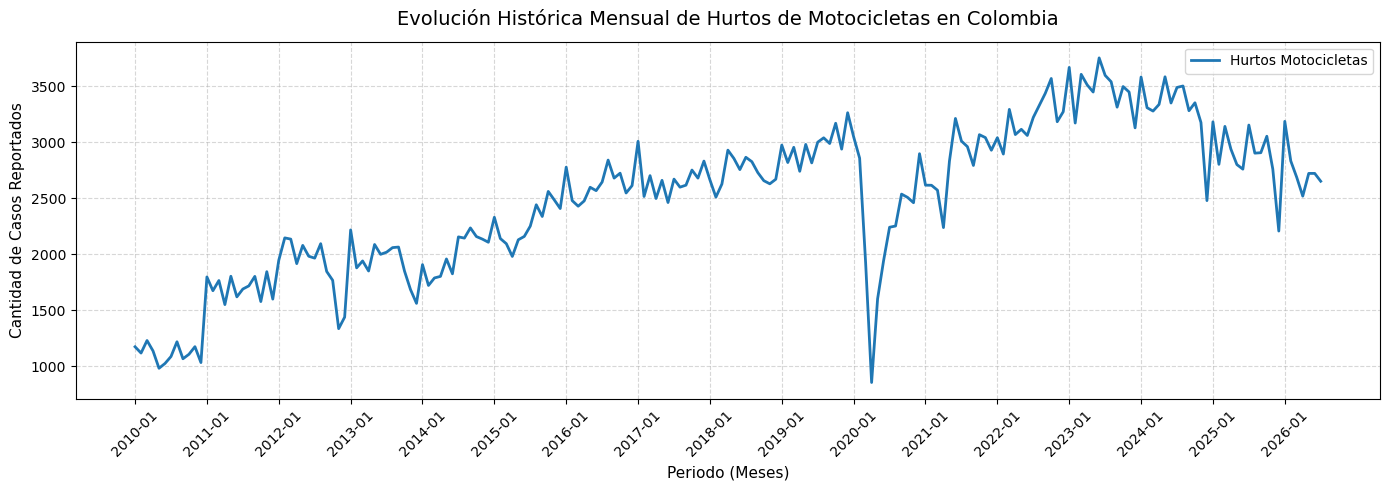

In [15]:
# Visualización analítica preliminar
plt.figure(figsize=(14, 5))
plt.plot(range(len(df_serie_motos)), df_serie_motos['total_hurtos_motocicletas'], color='#1f77b4', linewidth=2, label='Hurtos Motocicletas')
plt.title('Evolución Histórica Mensual de Hurtos de Motocicletas en Colombia', fontsize=14, pad=12)
plt.xlabel('Periodo (Meses)', fontsize=11)
plt.ylabel('Cantidad de Casos Reportados', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Ticks cada 12 meses
step = 12
plt.xticks(range(0, len(df_serie_motos), step), df_serie_motos['año_mes'].iloc[::step], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Cierre ordenado de la conexión
conn.close()
print("Conexión a base de datos cerrada ordenadamente.")

## 10. Pregunta de Reflexión para el Proyecto

> **Pregunta:**  
> *En el mundo real, el ETL se ejecuta de forma recurrente (cada noche, cada hora).  
> ¿Cómo cambiaría tu pipeline si en vez de cargar toda la data siempre (`if_exists='replace'`), necesitas solo agregar registros nuevos sin duplicar los existentes?*

---

### Análisis y Propuesta Arquitectónica del Grupo de Trabajo:

Si el pipeline debe ejecutarse de forma recurrente en producción (por ejemplo, mediante orquestadores como Apache Airflow, Prefect o Cron Jobs nocturnos), sustituir la estrategia de **Carga Completa (`Full Load / Replace`)** por una estrategia de **Carga Incremental (`Delta Load` / `CDC - Change Data Capture`)** requeriría los siguientes cambios fundamentales en las fases de Extracción, Transformación y Carga:

#### 1. Extracción Incremental y Mecanismo de Marcas de Agua (High Watermark)
- En lugar de descargar y procesar los 656.635 registros históricos cada noche, el proceso de extracción consultaría únicamente los registros con fecha de reporte o modificación posterior a la última ejecución exitosa:
  $$\text{FECHA HECHO} \ge \text{Watermark}_{\text{anterior}} - \Delta t_{\text{gracia}}$$
- Se incluye una pequeña ventana de gracia (por ejemplo, 48 a 72 horas hacia atrás) para capturar posibles denuncias ingresadas con rezago administrativo por las estaciones de policía.

#### 2. Gestión de Tablas Dimensionales (Slowly Changing Dimensions - SCD)
- **Nuevas Entidades:** Si en el lote diario aparece un municipio nunca antes reportado o una nueva variante de arma, se extrae el valor máximo actual de la clave subrogada (`MAX(municipio_key) + 1`) y se inserta el nuevo registro.
- **Técnicas de Inserción Protegida:** Se utilizarían sentencias con control de duplicados como `INSERT OR IGNORE` en SQLite o cláusulas `ON CONFLICT (codigo_dane_mpio) DO UPDATE...` (UPSERT) en PostgreSQL.
- **SCD Tipo 2:** Si los atributos de una dimensión cambian con el tiempo (por ejemplo, la reclasificación territorial de un municipio o cambio de jurisdicción policial), se incorporarían columnas de control (`fecha_inicio`, `fecha_fin`, `registro_actual`) para conservar el historial analítico.

#### 3. Inserción Idempotente en la Tabla de Hechos (`FACT_HURTOS`)
- Debido a que el dataset de la Policía no posee un número de denuncia unívoco en origen, se crearía una **clave natural combinada de negocio o hash determinístico**:
  $$\text{Hash}_{\text{hecho}} = \text{MD5}(\text{FECHA} \parallel \text{CODIGO DANE} \parallel \text{TIPO DE HURTO} \parallel \text{ARMA} \parallel \text{GENERO} \parallel \text{GRUPO ETARIO})$$
- En SQLite / PostgreSQL, la carga se realizaría primero sobre una tabla temporal de aterrizaje (*Staging Table*), insertando en la tabla productiva únicamente los registros inexistentes:
```sql
-- Carga idempotente hacia la tabla de hechos
INSERT INTO fact_hurtos (fecha_key, municipio_key, tipo_hurto_key, arma_medio_key, victima_key, cantidad)
SELECT 
    s.fecha_key, 
    s.municipio_key, 
    s.tipo_hurto_key, 
    s.arma_medio_key, 
    s.victima_key, 
    s.cantidad
FROM staging_fact_hurtos s
WHERE NOT EXISTS (
    SELECT 1 FROM fact_hurtos f
    WHERE f.fecha_key = s.fecha_key
      AND f.municipio_key = s.municipio_key
      AND f.tipo_hurto_key = s.tipo_hurto_key
      AND f.arma_medio_key = s.arma_medio_key
      AND f.victima_key = s.victima_key
);
```

#### 4. Transaccionalidad Atómica (ACID) y Trazabilidad (Logging)
- Todo el lote de carga se ejecutaría dentro de una transacción (`BEGIN TRANSACTION ... COMMIT`). Ante cualquier falla durante la asignación de claves o escritura en disco, se dispara un `ROLLBACK` automático, impidiendo estados corruptos o cargas parciales.
- Se implementaría una tabla de auditoría (`etl_execution_log`) que registre la fecha de inicio, fecha de fin, cantidad de filas leídas, cantidad de filas insertadas y estado final de cada corrida.